In [4]:
import pandas as pd

In [26]:
print("Colunas - Crash: ", df_crash.columns.tolist())
print("Colunas - Vehicle: ", df_vehicle.columns.tolist())
print("Colunas - People: ", df_people.columns.tolist())

Colunas - Crash:  ['CRASH_RECORD_ID', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'NUM_UNITS', 'CRASH_MONTH', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'IDOT_CONTROL_NO', 'LATITUDE', 'LONGITUDE', 'LOCATION']
Colunas - Vehicle:  ['CRASH_UNIT_ID', 'CRASH_RECORD_ID', 'CRASH_DATE', 'UNIT_NO', 'UNIT_TYPE', 'VEHICLE_ID', 'MAKE', 'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR', 'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION', 'MANEUVER', 'OCC

NameError: name 'df_people' is not defined

In [27]:
df_crash.to_csv('crash_data_new.csv', index=False)

# Base Acidente



In [5]:
df_crash = pd.read_csv('datasets/crash.csv', low_memory=False)

In [6]:
df_crash.shape

(1069048, 49)

In [7]:
df_crash.info()

<class 'pandas.DataFrame'>
RangeIndex: 1069048 entries, 0 to 1069047
Data columns (total 49 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH_RECORD_ID                1069048 non-null  str    
 1   CRASH_DATE_EST_I               77289 non-null    str    
 2   CRASH_DATE                     1069048 non-null  str    
 3   POSTED_SPEED_LIMIT             1069048 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         1069048 non-null  str    
 5   DEVICE_CONDITION               1069048 non-null  str    
 6   WEATHER_CONDITION              1069048 non-null  str    
 7   LIGHTING_CONDITION             1069048 non-null  str    
 8   FIRST_CRASH_TYPE               1069048 non-null  str    
 9   TRAFFICWAY_TYPE                1069048 non-null  str    
 10  LANE_CNT                       199044 non-null   str    
 11  ALIGNMENT                      1069048 non-null  str    
 12  ROADWAY_SURFACE_COND     

In [8]:
info_colunas = pd.DataFrame({
    "coluna": df_crash.columns,
    "tipo": df_crash.dtypes.astype(str),
    "qtd_nao_nulos": df_crash.notna().sum().values,
    "qtd_nulos": df_crash.isna().sum().values,
    "perc_nulos": (df_crash.isna().mean().values * 100).round(2),
    "qtd_valores_unicos": df_crash.nunique(dropna=True).values
})

info_colunas

,coluna,tipo,qtd_nao_nulos,qtd_nulos,perc_nulos,qtd_valores_unicos
CRASH_RECORD_ID,CRASH_RECORD_ID,str,1069048,0,0.00,1069048
CRASH_DATE_EST_I,CRASH_DATE_EST_I,str,77289,991759,92.77,2
CRASH_DATE,CRASH_DATE,str,1069048,0,0.00,708374
POSTED_SPEED_LIMIT,POSTED_SPEED_LIMIT,int64,1069048,0,0.00,47
TRAFFIC_CONTROL_DEVICE,TRAFFIC_CONTROL_DEVICE,str,1069048,0,0.00,19
DEVICE_CONDITION,DEVICE_CONDITION,str,1069048,0,0.00,8
WEATHER_CONDITION,WEATHER_CONDITION,str,1069048,0,0.00,12
LIGHTING_CONDITION,LIGHTING_CONDITION,str,1069048,0,0.00,6
FIRST_CRASH_TYPE,FIRST_CRASH_TYPE,str,1069048,0,0.00,18
TRAFFICWAY_TYPE,TRAFFICWAY_TYPE,str,1069048,0,0.00,20


In [9]:
colunas_numericas = df_crash.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = df_crash.select_dtypes(include=["str"]).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_numericas))
print("Quantidade de colunas categóricas:", len(colunas_categoricas))

Quantidade de colunas numéricas: 16
Quantidade de colunas categóricas: 33


In [10]:
colunas_numericas

['POSTED_SPEED_LIMIT',
 'STREET_NO',
 'BEAT_OF_OCCURRENCE',
 'NUM_UNITS',
 'CRASH_MONTH',
 'INJURIES_TOTAL',
 'INJURIES_FATAL',
 'INJURIES_INCAPACITATING',
 'INJURIES_NON_INCAPACITATING',
 'INJURIES_REPORTED_NOT_EVIDENT',
 'INJURIES_NO_INDICATION',
 'INJURIES_UNKNOWN',
 'CRASH_HOUR',
 'CRASH_DAY_OF_WEEK',
 'LATITUDE',
 'LONGITUDE']

In [11]:
colunas_categoricas

['CRASH_RECORD_ID',
 'CRASH_DATE_EST_I',
 'CRASH_DATE',
 'TRAFFIC_CONTROL_DEVICE',
 'DEVICE_CONDITION',
 'WEATHER_CONDITION',
 'LIGHTING_CONDITION',
 'FIRST_CRASH_TYPE',
 'TRAFFICWAY_TYPE',
 'LANE_CNT',
 'ALIGNMENT',
 'ROADWAY_SURFACE_COND',
 'ROAD_DEFECT',
 'REPORT_TYPE',
 'CRASH_TYPE',
 'INTERSECTION_RELATED_I',
 'NOT_RIGHT_OF_WAY_I',
 'HIT_AND_RUN_I',
 'DAMAGE',
 'DATE_POLICE_NOTIFIED',
 'PRIM_CONTRIBUTORY_CAUSE',
 'SEC_CONTRIBUTORY_CAUSE',
 'STREET_DIRECTION',
 'STREET_NAME',
 'PHOTOS_TAKEN_I',
 'STATEMENTS_TAKEN_I',
 'DOORING_I',
 'WORK_ZONE_I',
 'WORK_ZONE_TYPE',
 'WORKERS_PRESENT_I',
 'MOST_SEVERE_INJURY',
 'IDOT_CONTROL_NO',
 'LOCATION']

In [12]:
def plot_null_values(df):
    nulos = df.isna().sum().reset_index()
    nulos.columns = ["coluna", "qtd_nulos"]

    nulos["perc_nulos"] = (nulos["qtd_nulos"] / len(df) * 100).round(2)

    nulos = nulos.sort_values("perc_nulos", ascending=False)

    return nulos
plot_null_values(df_crash)

,coluna,qtd_nulos,perc_nulos
32,WORKERS_PRESENT_I,1067579,99.86
29,DOORING_I,1065646,99.68
31,WORK_ZONE_TYPE,1064691,99.59
30,WORK_ZONE_I,1063313,99.46
27,PHOTOS_TAKEN_I,1053574,98.55
28,STATEMENTS_TAKEN_I,1043137,97.58
17,NOT_RIGHT_OF_WAY_I,1021397,95.54
1,CRASH_DATE_EST_I,991759,92.77
10,LANE_CNT,870004,81.38
16,INTERSECTION_RELATED_I,823480,77.03


In [13]:
cols_to_drop = [
    'WORKERS_PRESENT_I',
    'DOORING_I',
    'WORK_ZONE_TYPE',
    'WORK_ZONE_I',
    'PHOTOS_TAKEN_I',
    'STATEMENTS_TAKEN_I',
    'NOT_RIGHT_OF_WAY_I',
    'CRASH_DATE_EST_I',
    'LANE_CNT',
    'INTERSECTION_RELATED_I',
    'HIT_AND_RUN_I'
]

# Remove apenas as colunas que existem no DataFrame
df_crash = df_crash.drop(columns=[col for col in cols_to_drop if col in df_crash.columns])

plot_null_values(df_crash)

,coluna,qtd_nulos,perc_nulos
12,REPORT_TYPE,36168,3.38
36,LONGITUDE,8269,0.77
37,LOCATION,8269,0.77
35,LATITUDE,8269,0.77
34,IDOT_CONTROL_NO,2806,0.26
27,INJURIES_INCAPACITATING,2308,0.22
26,INJURIES_FATAL,2308,0.22
29,INJURIES_REPORTED_NOT_EVIDENT,2308,0.22
30,INJURIES_NO_INDICATION,2308,0.22
31,INJURIES_UNKNOWN,2308,0.22


In [14]:
df_crash = df_crash.dropna()
plot_null_values(df_crash)

,coluna,qtd_nulos,perc_nulos
0,CRASH_RECORD_ID,0,0.0
1,CRASH_DATE,0,0.0
2,POSTED_SPEED_LIMIT,0,0.0
3,TRAFFIC_CONTROL_DEVICE,0,0.0
4,DEVICE_CONDITION,0,0.0
5,WEATHER_CONDITION,0,0.0
6,LIGHTING_CONDITION,0,0.0
7,FIRST_CRASH_TYPE,0,0.0
8,TRAFFICWAY_TYPE,0,0.0
9,ALIGNMENT,0,0.0


## Duplicatas

In [15]:
duplicadas = df_crash.duplicated().sum()

print("Quantidade de linhas duplicadas:", duplicadas)
print("Percentual de linhas duplicadas:", round(duplicadas / len(df_crash) * 100, 2))

Quantidade de linhas duplicadas: 0
Percentual de linhas duplicadas: 0.0


# Base Veiculos

In [16]:
df_vehicle = pd.read_csv('datasets/vehicle.csv', low_memory=False)

In [17]:
print(f"A base possui {df_vehicle.shape[0]} linhas e {df_vehicle.shape[1]} colunas.")

A base possui 2179677 linhas e 71 colunas.


In [18]:
df_vehicle.info()

<class 'pandas.DataFrame'>
RangeIndex: 2179677 entries, 0 to 2179676
Data columns (total 71 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   CRASH_UNIT_ID             int64  
 1   CRASH_RECORD_ID           str    
 2   CRASH_DATE                str    
 3   UNIT_NO                   str    
 4   UNIT_TYPE                 str    
 5   NUM_PASSENGERS            float64
 6   VEHICLE_ID                float64
 7   CMRC_VEH_I                str    
 8   MAKE                      str    
 9   MODEL                     str    
 10  LIC_PLATE_STATE           str    
 11  VEHICLE_YEAR              float64
 12  VEHICLE_DEFECT            str    
 13  VEHICLE_TYPE              str    
 14  VEHICLE_USE               str    
 15  TRAVEL_DIRECTION          str    
 16  MANEUVER                  str    
 17  TOWED_I                   str    
 18  FIRE_I                    str    
 19  OCCUPANT_CNT              float64
 20  EXCEED_SPEED_LIMIT_I      str    
 

In [19]:
colunas_num_vehicle = df_vehicle.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_cat_vehicle = df_vehicle.select_dtypes(include=["str"]).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_num_vehicle))
print("Quantidade de colunas categóricas:", len(colunas_cat_vehicle))

Quantidade de colunas numéricas: 8
Quantidade de colunas categóricas: 63


In [20]:
plot_null_values(df_vehicle)

,coluna,qtd_nulos,perc_nulos
54,MCS_REPORT_NO,2179668,100.00
48,HAZMAT_NAME,2179607,100.00
62,TRAILER2_LENGTH,2179603,100.00
52,HAZMAT_REPORT_NO,2179674,100.00
58,WIDE_LOAD_I,2179488,99.99
...,...,...,...
4,UNIT_TYPE,2464,0.11
3,UNIT_NO,0,0.00
0,CRASH_UNIT_ID,0,0.00
1,CRASH_RECORD_ID,0,0.00


In [21]:
limite_nulos = 0.50

# Calcula a proporção de valores nulos por coluna
percentual_nulos = df_vehicle.isnull().mean()

# Seleciona colunas com mais de 50% de valores nulos
cols_to_drop = percentual_nulos[percentual_nulos > limite_nulos].index

# Remove as colunas
df_vehicle = df_vehicle.drop(columns=cols_to_drop)

# Visualiza novamente
plot_null_values(df_vehicle)

,coluna,qtd_nulos,perc_nulos
9,VEHICLE_YEAR,383378,17.59
8,LIC_PLATE_STATE,245968,11.28
16,FIRST_CONTACT_POINT,55444,2.54
12,VEHICLE_USE,52223,2.40
7,MODEL,52373,2.40
10,VEHICLE_DEFECT,52223,2.40
11,VEHICLE_TYPE,52223,2.40
5,VEHICLE_ID,52223,2.40
6,MAKE,52228,2.40
14,MANEUVER,52223,2.40


In [22]:
df_vehicle = df_vehicle.dropna()
plot_null_values(df_vehicle)

,coluna,qtd_nulos,perc_nulos
0,CRASH_UNIT_ID,0,0.0
1,CRASH_RECORD_ID,0,0.0
2,CRASH_DATE,0,0.0
3,UNIT_NO,0,0.0
4,UNIT_TYPE,0,0.0
5,VEHICLE_ID,0,0.0
6,MAKE,0,0.0
7,MODEL,0,0.0
8,LIC_PLATE_STATE,0,0.0
9,VEHICLE_YEAR,0,0.0


In [23]:
duplicadas = df_vehicle.duplicated().sum()

print("Quantidade de linhas duplicadas:", duplicadas)
print("Percentual de linhas duplicadas:", round(duplicadas / len(df_vehicle) * 100, 2))

Quantidade de linhas duplicadas: 0
Percentual de linhas duplicadas: 0.0


In [24]:
df_vehicle.info()

<class 'pandas.DataFrame'>
Index: 1740361 entries, 0 to 2179676
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   CRASH_UNIT_ID        int64  
 1   CRASH_RECORD_ID      str    
 2   CRASH_DATE           str    
 3   UNIT_NO              str    
 4   UNIT_TYPE            str    
 5   VEHICLE_ID           float64
 6   MAKE                 str    
 7   MODEL                str    
 8   LIC_PLATE_STATE      str    
 9   VEHICLE_YEAR         float64
 10  VEHICLE_DEFECT       str    
 11  VEHICLE_TYPE         str    
 12  VEHICLE_USE          str    
 13  TRAVEL_DIRECTION     str    
 14  MANEUVER             str    
 15  OCCUPANT_CNT         float64
 16  FIRST_CONTACT_POINT  str    
dtypes: float64(3), int64(1), str(13)
memory usage: 239.0 MB


In [25]:
corr = df_vehicle[colunas_num_vehicle].corr(numeric_only=True)

corr

KeyError: "['NUM_PASSENGERS', 'TRAILER1_LENGTH', 'TRAILER2_LENGTH', 'TOTAL_VEHICLE_LENGTH'] not in index"

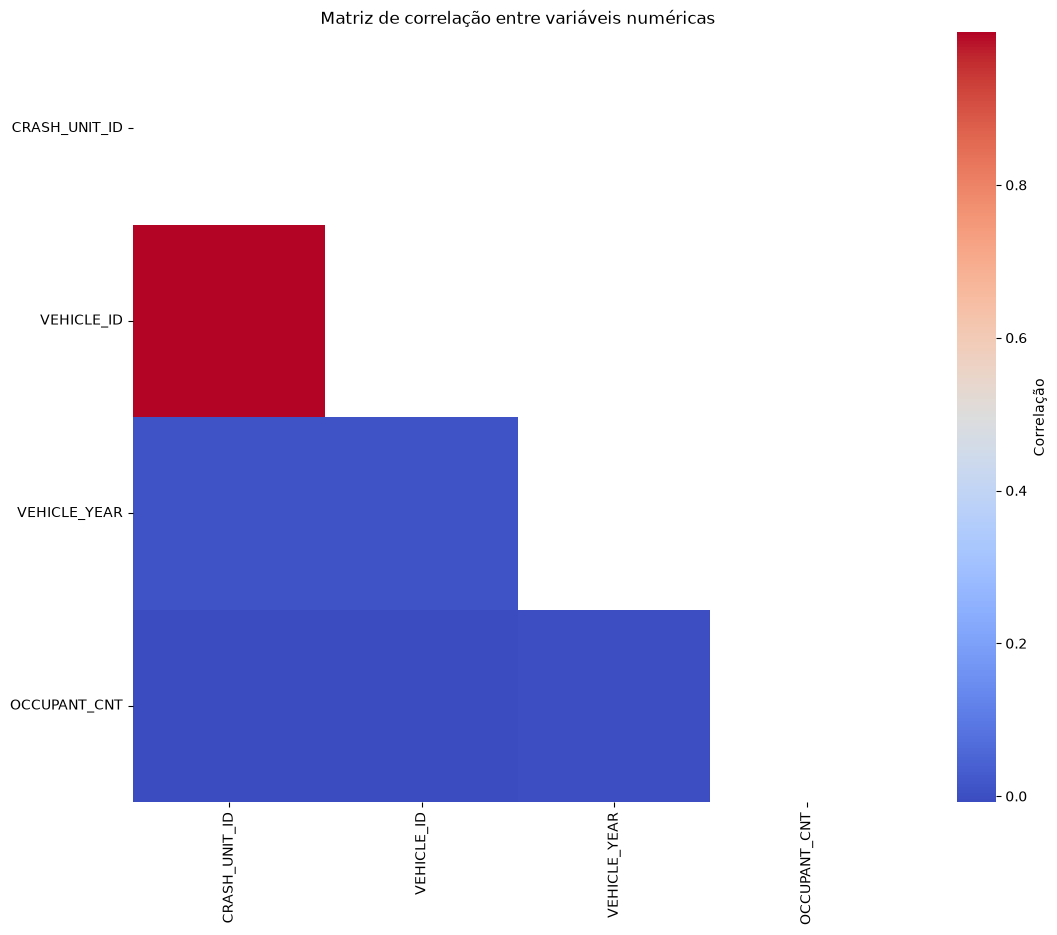

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# máscara para esconder a metade superior da matriz
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=False,   # coloque True se quiser mostrar os valores
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Correlação"}
)

plt.title("Matriz de correlação entre variáveis numéricas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Base pessoas

In [ ]:
df_people = pd.read_csv('datasets/people.csv', low_memory=False)

In [ ]:
print(f"A base possui {df_people.shape[0]} linhas e {df_people.shape[1]} colunas.")

A base possui 2346694 linhas e 29 colunas.


In [ ]:
df_people.info()

<class 'pandas.DataFrame'>
RangeIndex: 2346694 entries, 0 to 2346693
Data columns (total 29 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   PERSON_ID              str    
 1   PERSON_TYPE            str    
 2   CRASH_RECORD_ID        str    
 3   VEHICLE_ID             float64
 4   CRASH_DATE             str    
 5   SEAT_NO                float64
 6   CITY                   str    
 7   STATE                  str    
 8   ZIPCODE                str    
 9   SEX                    str    
 10  AGE                    float64
 11  DRIVERS_LICENSE_STATE  str    
 12  DRIVERS_LICENSE_CLASS  str    
 13  SAFETY_EQUIPMENT       str    
 14  AIRBAG_DEPLOYED        str    
 15  EJECTION               str    
 16  INJURY_CLASSIFICATION  str    
 17  HOSPITAL               str    
 18  EMS_AGENCY             str    
 19  EMS_RUN_NO             str    
 20  DRIVER_ACTION          str    
 21  DRIVER_VISION          str    
 22  PHYSICAL_CONDITION     str   

In [ ]:
colunas_num_people = df_people.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_cat_people = df_people.select_dtypes(include=["str"]).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_num_people))
print("Quantidade de colunas categóricas:", len(colunas_cat_people))

Quantidade de colunas numéricas: 3
Quantidade de colunas categóricas: 26


In [ ]:
plot_null_values(df_people)

,coluna,qtd_nulos,perc_nulos
28,CELL_PHONE_USE,2345532,99.95
27,BAC_RESULT VALUE,2344150,99.89
19,EMS_RUN_NO,2308964,98.39
24,PEDPEDAL_VISIBILITY,2299182,97.98
23,PEDPEDAL_ACTION,2299095,97.97
25,PEDPEDAL_LOCATION,2299095,97.97
18,EMS_AGENCY,2122792,90.46
17,HOSPITAL,1982758,84.49
5,SEAT_NO,1874099,79.86
12,DRIVERS_LICENSE_CLASS,1211591,51.63


In [ ]:
limite_nulos = 0.4

# Calcula a proporção de valores nulos por coluna
percentual_nulos = df_people.isnull().mean()

# Seleciona colunas com mais de 50% de valores nulos
cols_to_drop = percentual_nulos[percentual_nulos > limite_nulos].index

# Remove as colunas
df_people = df_people.drop(columns=cols_to_drop)

# Visualiza novamente
plot_null_values(df_people)

,coluna,qtd_nulos,perc_nulos
7,ZIPCODE,766480,32.66
9,AGE,680112,28.98
5,CITY,637488,27.17
6,STATE,610838,26.03
15,DRIVER_VISION,477534,20.35
14,DRIVER_ACTION,476764,20.32
17,BAC_RESULT,475905,20.28
16,PHYSICAL_CONDITION,475492,20.26
3,VEHICLE_ID,49596,2.11
11,AIRBAG_DEPLOYED,47730,2.03


In [ ]:
cols_to_drop = [
    'ZIPCODE',
    'CITY',
    'STATE',
    'WORK_ZONE_I',
    'PHOTOS_TAKEN_I',
    'STATEMENTS_TAKEN_I',
    'NOT_RIGHT_OF_WAY_I',
    'CRASH_DATE_EST_I',
    'LANE_CNT',
    'INTERSECTION_RELATED_I',
    'HIT_AND_RUN_I'
]

# Remove apenas as colunas que existem no DataFrame
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

plot_null_values(df)

NameError: name 'df' is not defined